## Module 3: Vibe Mapping & Playlist Recommendation

**Objective:** Wire in the CLIP image encoder to build the full end-to-end pipeline:
image → vibe detection → genre filtering → cosine similarity → playlist.

**Key Operations:**
* **Vibe Taxonomy:** 12 scene categories, each defined by a natural-language probe text and a label.
* **Vibe Detection:** Encode the uploaded image and compare it against all vibe probes to identify the dominant scene type.
* **Genre Filtering:** Children's genres (`children`, `kids`, `disney`) are permanently excluded from the song pool.
* **Recommendation:** Rank the filtered song pool by cosine similarity to the image embedding and return the top-K playlist.

---
Requires outputs from `02_clip_setup.ipynb`:
- `data/song_embeddings.npy` — precomputed song text embeddings `[61670, 512]`
- `data/song_index.csv` — row-aligned song metadata

In [11]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pillow-heif', '--quiet'], check=True)

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import clip
from PIL import Image
import pillow_heif
pillow_heif.register_heif_opener()   # adds HEIC/HEIF support to PIL

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

song_embeddings_all = np.load("../data/song_embeddings.npy")
index_df_all        = pd.read_csv("../data/song_index.csv")

assert len(song_embeddings_all) == len(index_df_all), "Embedding matrix and index are misaligned."

# Permanently remove children's genres from the song pool
KIDS_GENRES = "children|kids|disney"
keep_mask       = ~index_df_all["merged_genres"].str.contains(KIDS_GENRES, case=False, na=False)
song_embeddings = song_embeddings_all[keep_mask.values]
index_df        = index_df_all[keep_mask.values].reset_index(drop=True)

print(f"Device              : {device}")
print(f"Total songs loaded  : {len(index_df_all):,}")
print(f"After kids filter   : {len(index_df):,} ({len(index_df_all)-len(index_df):,} removed)")
print(f"Song embeddings     : {song_embeddings.shape}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Device              : cpu
Total songs loaded  : 61,670
After kids filter   : 60,082 (1,588 removed)
Song embeddings     : (60082, 512)


---
### 1. Vibe taxonomy

Each vibe is defined by:
- A **label**: short human-readable name shown to the user
- A **probe**: natural-language description that CLIP encodes into a 512-d vector

Vibe detection works by comparing the image embedding to all probe embeddings and picking the closest match.

In [12]:
VIBE_TAXONOMY = {
    "cozy_cafe": {
        "label": "Cozy Cafe",
        "probe": "a cozy coffee shop with warm lighting and soft background music",
    },
    "winter_snow": {
        "label": "Winter / Snow",
        "probe": "a quiet snowy street on a cold winter evening",
    },
    "beach_summer": {
        "label": "Beach / Summer",
        "probe": "a bright sunny beach in summer with people relaxing",
    },
    "rainy_melancholic": {
        "label": "Rainy / Melancholic",
        "probe": "a rainy night alone in the city feeling nostalgic and sad",
    },
    "party_energetic": {
        "label": "Party / Energetic",
        "probe": "a high-energy dance party with flashing lights and a dancing crowd",
    },
    "romantic_evening": {
        "label": "Romantic Evening",
        "probe": "a candlelit romantic dinner setting at night",
    },
    "nature_peaceful": {
        "label": "Nature / Peaceful",
        "probe": "a peaceful walk through green forests and nature trails",
    },
    "urban_hustle": {
        "label": "Urban / Hustle",
        "probe": "a busy city street at midday with crowds and tall buildings",
    },
    "late_night_drive": {
        "label": "Late Night Drive",
        "probe": "driving alone on a dark highway at night with city lights in the distance",
    },
    "morning_calm": {
        "label": "Morning / Calm",
        "probe": "a calm peaceful morning at home with soft sunlight coming through the window",
    },
    "dark_moody": {
        "label": "Dark / Moody",
        "probe": "a dark moody aesthetic with deep shadows and muted tones",
    },
    "festival_concert": {
        "label": "Festival / Concert",
        "probe": "an outdoor music festival with a large crowd and a stage",
    },
}

vibe_keys   = list(VIBE_TAXONOMY.keys())
vibe_labels = [VIBE_TAXONOMY[k]["label"] for k in vibe_keys]
vibe_probes = [VIBE_TAXONOMY[k]["probe"] for k in vibe_keys]

print(f"{len(VIBE_TAXONOMY)} vibes defined:")
for key, label in zip(vibe_keys, vibe_labels):
    print(f"  {key:22s} → {label}")

12 vibes defined:
  cozy_cafe              → Cozy Cafe
  winter_snow            → Winter / Snow
  beach_summer           → Beach / Summer
  rainy_melancholic      → Rainy / Melancholic
  party_energetic        → Party / Energetic
  romantic_evening       → Romantic Evening
  nature_peaceful        → Nature / Peaceful
  urban_hustle           → Urban / Hustle
  late_night_drive       → Late Night Drive
  morning_calm           → Morning / Calm
  dark_moody             → Dark / Moody
  festival_concert       → Festival / Concert


In [13]:
# Precompute vibe probe embeddings — shape: [12, 512]
with torch.no_grad():
    tokens = clip.tokenize(vibe_probes, truncate=True).to(device)
    vibe_embeddings = model.encode_text(tokens)
    vibe_embeddings = F.normalize(vibe_embeddings, dim=-1).cpu().numpy()

print(f"Vibe probe embedding matrix: {vibe_embeddings.shape}")

Vibe probe embedding matrix: (12, 512)


---
### 2. Image-to-Playlist Pipeline

The full pipeline in four steps:

```
1. Image  ──► CLIP image encoder  ──► 512-d image embedding
                                              │
2.                                  cosine sim vs vibe probes
                                              │
                                        top vibe label
                                              │
3.                                       genre filter 
                                              │
4.                          cosine sim vs filtered song embeddings
                                              │
                                        top-K playlist
```

In [14]:
def recommend_from_image(image_path, top_k=10):
    """
    Given a local image path, return the detected vibe and a top-K playlist
    ranked by cosine similarity between the image embedding and song embeddings.
    """
    # 1: encode image
    try:
        pil_img = Image.open(image_path).convert("RGB")
    except Exception as e:
        raise ValueError(
            f"Could not open image: '{image_path}'.\n"
            f"If this is an iPhone photo it may be HEIC format — "
            f"re-save it as JPEG in the Photos app (Share → Save to Files → JPEG).\n"
            f"Original error: {e}"
        ) from e
    image = preprocess(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        img_emb = model.encode_image(image)
        img_emb = F.normalize(img_emb, dim=-1).cpu().numpy()   # [1, 512]

    # 2: detect top vibe
    vibe_sims   = (vibe_embeddings @ img_emb.T).squeeze()      # [13]
    top_vibe_idx = int(vibe_sims.argmax())
    top_vibe_key = vibe_keys[top_vibe_idx]
    top_vibe_lbl = vibe_labels[top_vibe_idx]
    top_vibe_score = float(vibe_sims[top_vibe_idx])

    # 3: rank by cosine similarity against the pre-filtered song pool
    song_sims = (song_embeddings @ img_emb.T).squeeze()        # [N]
    top_idx   = np.argsort(song_sims)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_idx):
        row = index_df.iloc[idx]
        results.append({
            "rank"       : rank + 1,
            "similarity" : round(float(song_sims[idx]), 4),
            "track_name" : row["track_name"],
            "artists"    : row["artists"],
            "genres"     : row["merged_genres"],
            "popularity" : int(row["popularity"]),
        })

    return top_vibe_key, top_vibe_lbl, top_vibe_score, vibe_sims, pd.DataFrame(results)


def show_result(image_path, top_k=10):
    """Run the pipeline and display the image alongside the playlist."""
    vibe_key, vibe_lbl, vibe_score, all_vibe_sims, playlist = recommend_from_image(
        image_path, top_k=top_k
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                              gridspec_kw={"width_ratios": [1, 1.6]})

    # Left: image
    axes[0].imshow(mpimg.imread(image_path))
    axes[0].axis("off")
    axes[0].set_title(f"Detected vibe: {vibe_lbl}\n(score: {vibe_score:.3f})",
                       fontsize=11)

    # Right: vibe similarity bar chart
    sorted_idx  = np.argsort(all_vibe_sims)[::-1]
    sorted_lbls = [vibe_labels[i] for i in sorted_idx]
    sorted_sims = [float(all_vibe_sims[i]) for i in sorted_idx]
    colors = ["steelblue" if vibe_labels[i] != vibe_lbl else "tomato" for i in sorted_idx]

    axes[1].barh(sorted_lbls[::-1], sorted_sims[::-1], color=colors[::-1])
    axes[1].set_xlim(0.2, 0.85)
    axes[1].set_xlabel("Cosine Similarity")
    axes[1].set_title("Vibe Similarity Scores", fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f"\nTop-{top_k} Playlist — {vibe_lbl} vibe\n")
    print(playlist.to_string(index=False))
    return playlist

---
### 3. Test on sample images

 Test: Coffee shop


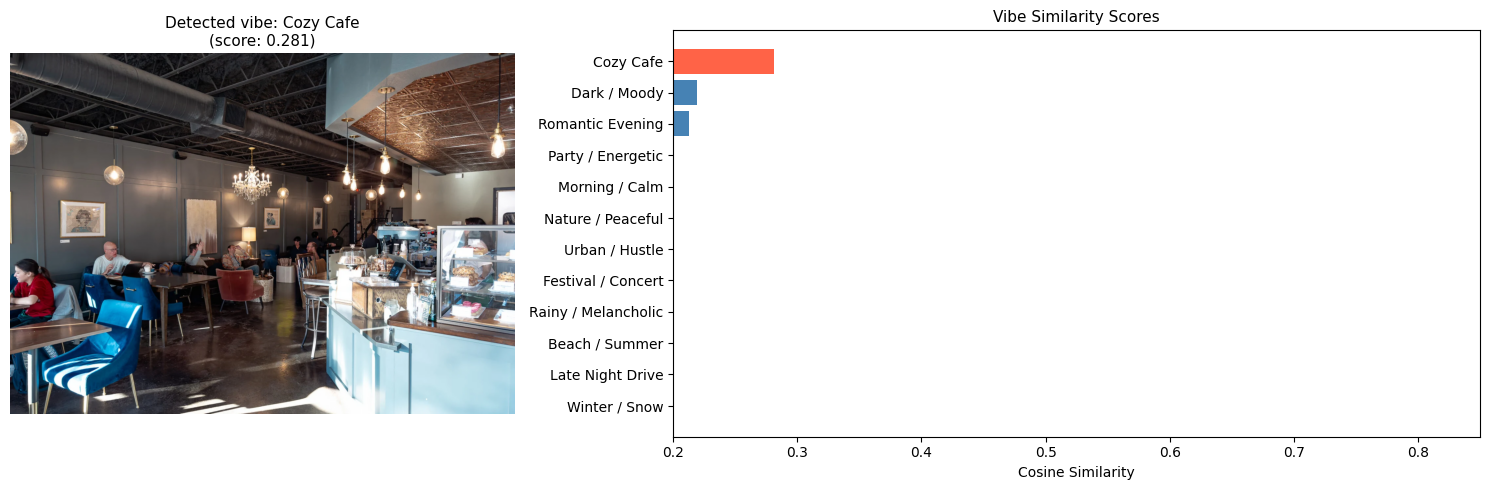


Top-10 Playlist — Cozy Cafe vibe

 rank  similarity                       track_name                artists         genres  popularity
    1      0.2308                     Coffee Stops             Beddy Rays         garage          31
    2      0.2281 Falling in Love at a Coffee Shop            Landon Pigg       acoustic          58
    3      0.2277           Asheville City Skyline      The Lonesome Trio      bluegrass          23
    4      0.2241                      Coffee Bean                  Turn.          study          43
    5      0.2234             Sovereign Light Café                  Keane          piano          62
    6      0.2234                  Coffe Cup Spots   Breakfast For Brunch          study          24
    7      0.2231                 Steampipe Coffee Circus No. 9;Jeff Sipe      bluegrass          21
    8      0.2230                   STAR CITY CAFE            hevel;Evito          chill          57
    9      0.2198            Sorrow & A Cup of Joe The O

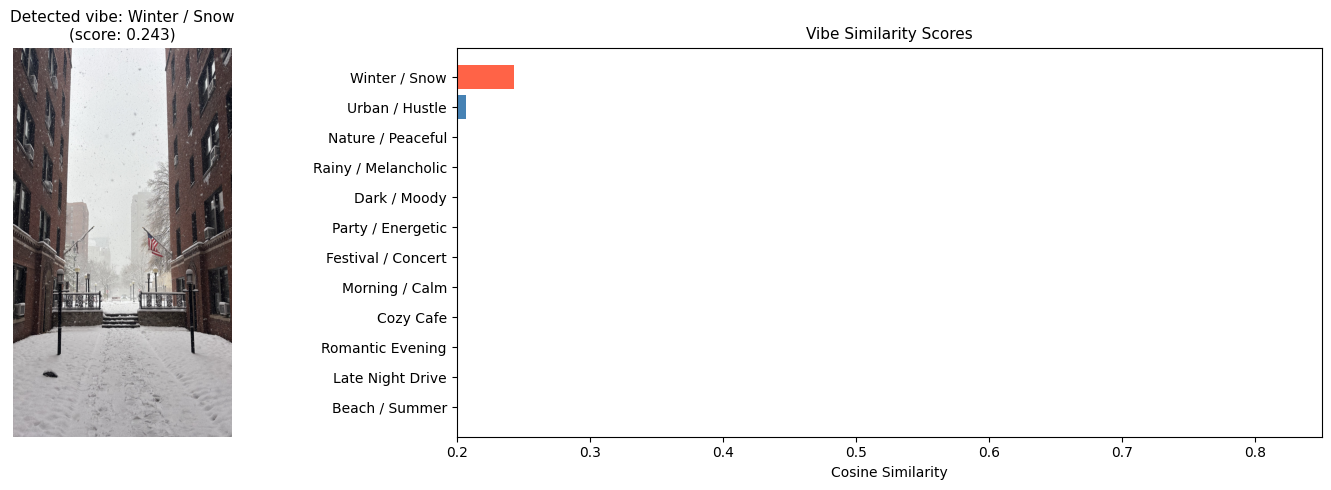


Top-10 Playlist — Winter / Snow vibe

 rank  similarity                                                          track_name                                                                                   artists     genres  popularity
    1      0.2610                              Let It Snow! Let It Snow! Let It Snow!                                                                               Dean Martin       jazz          68
    2      0.2601                                                   Winter Wonderland                                                                              Tony Bennett       jazz          39
    3      0.2569                                                    Boston City Hall                                                                                     Ewert      study          32
    4      0.2475 The Four Seasons - Winter in F Minor, RV. 297: I. Allegro non molto                                            Antonio Vivaldi;Adrian Chandler;La S

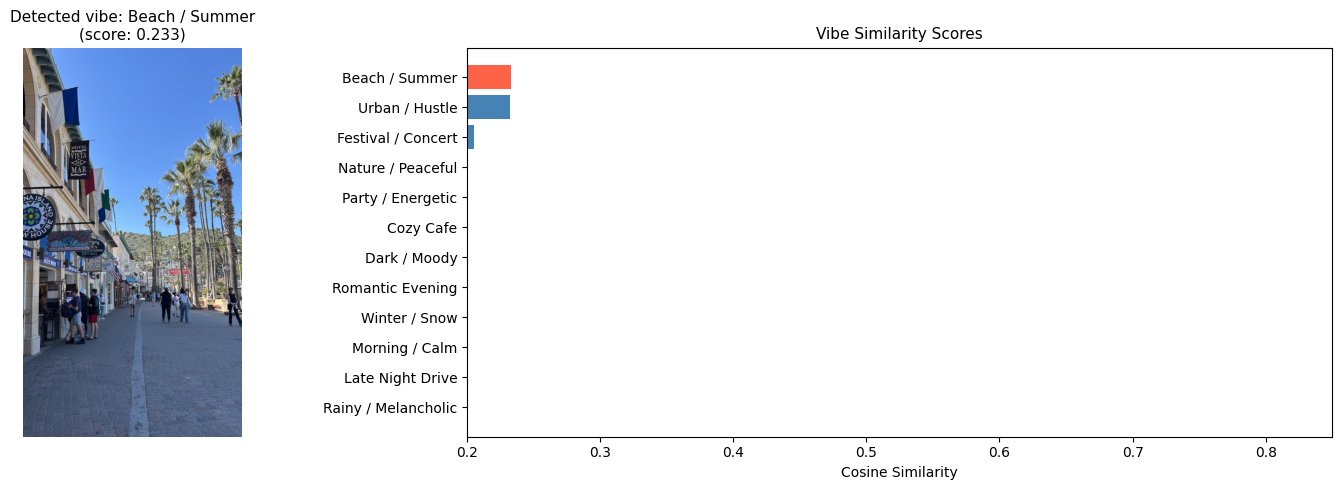


Top-10 Playlist — Beach / Summer vibe

 rank  similarity                                                    track_name                                                                                                                                                                                                                                                                                                                                                                                                                                     artists             genres  popularity
    1      0.2595         Mallorca Mallorca (Moviestar) - Oktoberfest Wiesn Mix                                                                                                                                                                                                                                                                                                                                                      

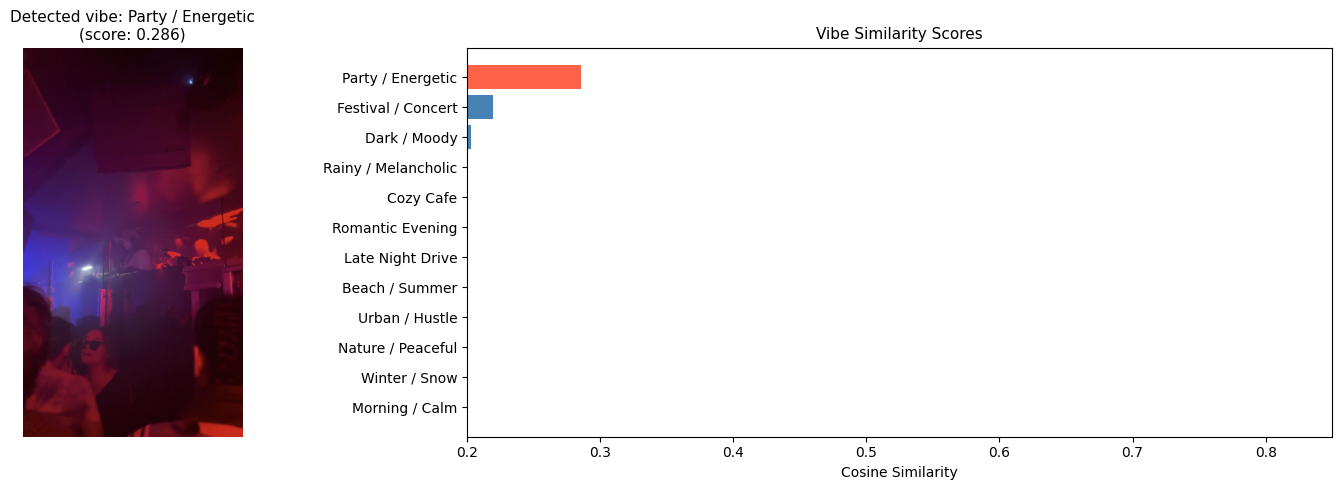


Top-10 Playlist — Party / Energetic vibe

 rank  similarity                                                               track_name                                               artists         genres  popularity
    1      0.2767                                                Party Shaker - Video Edit                                          R.I.O.;Nicco         german          58
    2      0.2757                                                         Tumbando El Club Neo Pistea;0-600;C.R.O;Mike Southside;Coqeéin Montana         latino          40
    3      0.2716                                          Don't Mug Yourself - Video Edit                                           The Streets         garage          27
    4      0.2716                                                               In da Club                            Tony Junior;Luis Rodriguez     deep-house          37
    5      0.2702                                      Mallorca Party Krieger - Video Edit       

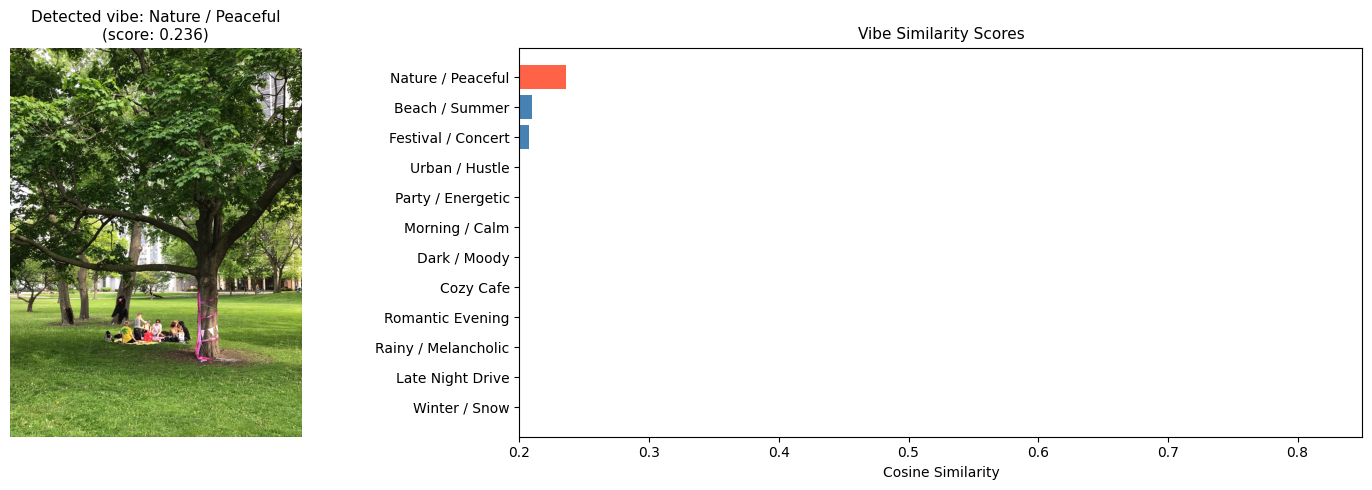


Top-10 Playlist — Nature / Peaceful vibe

 rank  similarity                                  track_name                                                                       artists         genres  popularity
    1      0.2599                   Views from Yamashita Park                                                              Nathan Kawanishi          study          51
    2      0.2515                                   City Park                                                                 Fleet Francis          study          30
    3      0.2487                                  Hands Down                                                                     2nd Grade      power-pop          21
    4      0.2479                                 Pullen Park                                                   Sarah, the Illstrumentalist          study          32
    5      0.2432                     Younger Than Springtime                                                             

In [15]:
os.makedirs("../data/sample_images", exist_ok=True)

TEST_IMAGES = {
    "Coffee shop" : "../data/sample_images/coffee_shop.jpg",
    "Snowy street": "../data/sample_images/snow_street.jpg",
    "Bright summer": "../data/sample_images/bright_summer.jpg",
    "Party"       : "../data/sample_images/party.jpg",
    "Nature"      : "../data/sample_images/nature.jpg",
}

# Run whichever images exist
for name, path in TEST_IMAGES.items():
    if os.path.exists(path):
        print(f"{'='*60}")
        print(f" Test: {name}")
        print(f"{'='*60}")
        show_result(path, top_k=10)
        print()
    else:
        print(f"[skipped] {name} — file not found at {path}")

---
### 4. Vibe detection: all scores

This cell shows the full vibe similarity breakdown for a single image.

In [17]:
IMAGE_PATH = "../data/sample_images/coffee_shop.jpg"

image = preprocess(Image.open(IMAGE_PATH).convert("RGB")).unsqueeze(0).to(device)
with torch.no_grad():
    img_emb = model.encode_image(image)
    img_emb = F.normalize(img_emb, dim=-1).cpu().numpy()

sims = (vibe_embeddings @ img_emb.T).squeeze()
vibe_score_df = pd.DataFrame({
    "vibe"      : vibe_labels,
    "similarity": sims.round(4),
}).sort_values("similarity", ascending=False).reset_index(drop=True)

print(f"Vibe scores for: {IMAGE_PATH}\n")
print(vibe_score_df.to_string(index=False))

Vibe scores for: ../data/sample_images/coffee_shop.jpg

               vibe  similarity
          Cozy Cafe      0.2812
       Dark / Moody      0.2189
   Romantic Evening      0.2125
  Party / Energetic      0.1946
     Morning / Calm      0.1932
  Nature / Peaceful      0.1784
     Urban / Hustle      0.1648
 Festival / Concert      0.1638
Rainy / Melancholic      0.1633
     Beach / Summer      0.1529
   Late Night Drive      0.1420
      Winter / Snow      0.1358


---
### Summary

The song similarity score measures how close is to the image directly (not to the vibe label).  
The vibe detection and the song ranking are two separate comparisons, both starting from the same image embedding:

```
Image
  │
  ▼
CLIP image encoder → 512-d image embedding
  │
  ├──► vs. 12 vibe probe embeddings  →  top vibe label  (used for display only)
  │
  └──► vs. 61,670 song embeddings    →  similarity score per song  →  top-K playlist
```

- **Vibe similarity** compares the image against 12 short scene descriptions ("a cozy coffee shop with warm lighting..."). This tells you *what kind of scene* CLIP detected in the image, and is shown as the label in the output.

- **Song similarity** compares the same image embedding against each song's `clip_metadata` embedding. This is what actually determines the playlist ranking; each song's score reflects how closely its described mood, genre, and sound match the image's visual content.

The vibe label does not filter or re-rank the songs. It is a human-readable summary of what CLIP saw in the image, added for interpretability. The playlist is ranked purely by cosine similarity between the image and the songs.